In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

In [10]:
#Load Dataset
csv_path = "/content/drive/MyDrive/EGG_DATASET/EEG-Eye-State.csv"
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (14980, 15)
Columns: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2', 'eyeDetection']


,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0


In [11]:

#Outlier Removal (IQR Filtering)
target_col = "eyeDetection"
features = [col for col in df.columns if col != target_col]

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((df[features] < lower_bound) | (df[features] > upper_bound)).any(axis=1)
df_clean = df[mask].reset_index(drop=True)

print(f"Original samples: {df.shape[0]}")
print(f"Cleaned samples: {df_clean.shape[0]}")
print(f"Removed outliers: {df.shape[0] - df_clean.shape[0]}")

Original samples: 14980
Cleaned samples: 11853
Removed outliers: 3127


In [12]:
#Feature Scaling (RobustScaler)
X_raw = df_clean[features].values
y_raw = df_clean[target_col].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (11853, 14)


In [13]:
#Sequence Creation & Train / Val / Test Split
def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_seq, y_seq = create_sequences(X_scaled, y_raw, time_steps=TIME_STEPS)

# Split: 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seq, y_seq, test_size=0.30, random_state=42, stratify=y_seq
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (8293, 5, 14), (8293,)
Validation set: (1777, 5, 14), (1777,)
Test set: (1778, 5, 14), (1778,)


In [14]:
# Build Regularized LSTM Architecture
model = Sequential([
    LSTM(32, input_shape=(TIME_STEPS, X_train.shape[2]), return_sequences=True, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(16, return_sequences=False, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 32)          │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,633 (37.63 KB)

 Trainable params: 9,537 (37.25 KB)

 Non-trainable params: 96 (384.00 B)

In [15]:
#Model Training with Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6499 - loss: 0.7106 - val_accuracy: 0.7704 - val_loss: 0.5991 - learning_rate: 0.0010
Epoch 2/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7719 - loss: 0.5498 - val_accuracy: 0.8756 - val_loss: 0.3897 - learning_rate: 0.0010
Epoch 3/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8331 - loss: 0.4554 - val_accuracy: 0.9122 - val_loss: 0.3053 - learning_rate: 0.0010
Epoch 4/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8666 - loss: 0.3993 - val_accuracy: 0.9297 - val_loss: 0.2629 - learning_rate: 0.0010
Epoch 5/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8893 - loss: 0.3423 - val_accuracy: 0.9308 - val_loss: 0.2421 - learning_rate: 0.0010
Epoch 6/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8993 - loss: 0.3176 - val_accuracy: 0.9460 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 7/50
260/260 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9080 - loss: 0

In [16]:
# Evaluate on Test Set & Classification Metrics
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final test accuracy: {acc * 100:.2f}%")
print(f"Final test loss: {loss:.4f}\n")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Eye Open (0)", "Eye Closed (1)"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final test accuracy: 98.20%
Final test loss: 0.0900

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Classification Report:
                precision    recall  f1-score   support

  Eye Open (0)       0.98      0.99      0.98       968
Eye Closed (1)       0.98      0.98      0.98       810

      accuracy                           0.98      1778
     macro avg       0.98      0.98      0.98      1778
  weighted avg       0.98      0.98      0.98      1778

Confusion Matrix:
[[954  14]
 [ 18 792]]


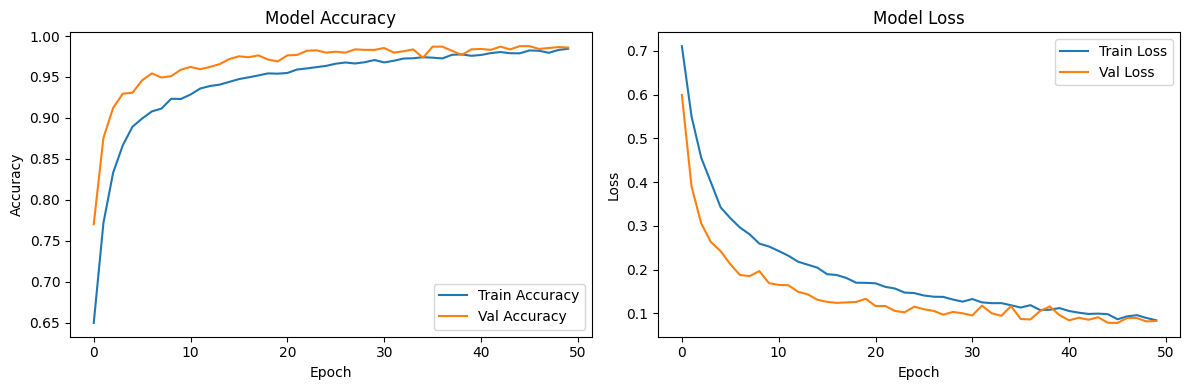

In [17]:
#Plot Training & Validation Learning Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
#Save Trained Model and Scaler
save_dir = "/content/drive/MyDrive/EGG_DATASET"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "eeg_lstm_model.keras")
scaler_path = os.path.join(save_dir, "eeg_robust_scaler.pkl")

model.save(model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: /content/drive/MyDrive/EGG_DATASET/eeg_lstm_model.keras
Scaler saved to: /content/drive/MyDrive/EGG_DATASET/eeg_robust_scaler.pkl


In [19]:
# Verification & Inference Test
loaded_model = tf.keras.models.load_model(model_path)
loaded_scaler = joblib.load(scaler_path)

sample_X = X_test[:5]
sample_y_true = y_test[:5]

predictions_prob = loaded_model.predict(sample_X)
predictions_class = (predictions_prob >= 0.5).astype(int).flatten()

print("--- Prediction Verification ---")
for i in range(len(sample_y_true)):
    status_pred = "Eye Closed (1)" if predictions_class[i] == 1 else "Eye Open (0)"
    status_true = "Eye Closed (1)" if sample_y_true[i] == 1 else "Eye Open (0)"
    prob = predictions_prob[i][0]
    print(f"Sample {i+1}: Predicted = {status_pred} (Prob: {prob:.4f}) | Actual = {status_true}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
--- Prediction Verification ---
Sample 1: Predicted = Eye Open (0) (Prob: 0.0004) | Actual = Eye Open (0)
Sample 2: Predicted = Eye Closed (1) (Prob: 0.9994) | Actual = Eye Closed (1)
Sample 3: Predicted = Eye Open (0) (Prob: 0.0015) | Actual = Eye Open (0)
Sample 4: Predicted = Eye Closed (1) (Prob: 1.0000) | Actual = Eye Closed (1)
Sample 5: Predicted = Eye Open (0) (Prob: 0.0002) | Actual = Eye Open (0)
